# Model 2C, Ensemble Experiment 01: CatBoost and MLP Probability Blend

This append-only experiment tests whether the fixed CatBoost 2C-02 and MLP 2C-01 models make sufficiently different errors for a simple probability blend to improve Model 2C. Neither component is retuned.

CatBoost uses 31 raw-taxi source fields plus numeric `MINUTES_TO_SCHEDULED_ARRIVAL`. The MLP uses the same 31 source fields and a fold-fitted spline of that margin. Five predeclared CatBoost weights—1.00, 0.75, 0.50, 0.25, and 0.00—include both pure components as controls.

Both components are regenerated on the same five expanding 2019 folds and identical rows. Mean fold average precision selects the weight. The operating threshold is selected from the aligned 2019 out-of-fold probabilities. The fixed components are then refitted on all 2019 rows, and only the selected blend is carried into the 2023 comparison. No probability or feature dataset is saved, and the 2024 dataset is not loaded.

In [1]:
import gc
import os
from pathlib import Path
from time import perf_counter

os.environ["MPLCONFIGDIR"] = "/tmp/matplotlib-capstone"
os.environ["XDG_CACHE_HOME"] = "/tmp/xdg-cache-capstone"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import catboost
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import tensorflow as tf
from catboost import CatBoostClassifier
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, SplineTransformer, StandardScaler
from tensorflow import keras
from tensorflow.keras import layers, regularizers

AIRPORT = "JFK"
TRAIN_YEAR = 2019
VALIDATION_YEAR = 2023
TARGET = "ArrDel15"
RANDOM_STATE = 42
N_TIME_SPLITS = 5
N_JOBS = 4

# Fixed CatBoost 2C-02 component.
CATBOOST_ITERATIONS = 364
CATBOOST_DEPTH = 6
CATBOOST_LEARNING_RATE = 0.03
CATBOOST_L2 = 10

# Fixed MLP 2C-01 component.
MLP_HIDDEN_UNITS = (64, 32)
MLP_LEARNING_RATE = 0.001
MLP_L2 = 0.0001
MLP_BATCH_SIZE = 512
MLP_EPOCHS = 11
SPLINE_KNOTS = 5
SPLINE_DEGREE = 3

CATBOOST_WEIGHTS = [1.00, 0.75, 0.50, 0.25, 0.00]

tf.keras.utils.set_random_seed(RANDOM_STATE)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
print(
    f"CatBoost {catboost.__version__}; TensorFlow {tf.__version__}; "
    f"scikit-learn {sklearn.__version__}"
)

CatBoost 1.2.10; TensorFlow 2.21.0; scikit-learn 1.9.0


## Load the shared arrival datasets and define the fixed inputs

Both components use the same flights and prediction time. Their only input difference is how the calculated schedule margin is presented to the classifier.

In [2]:
def find_project_root(start: Path, airport: str, years) -> Path:
    required = [
        Path("data/features") / f"{airport}_{year}_arrivals.csv"
        for year in years
    ]
    for candidate in (start, *start.parents):
        if all((candidate / path).is_file() for path in required):
            return candidate
    raise FileNotFoundError(f"Could not locate required feature datasets: {required}")


PROJECT_ROOT = find_project_root(Path.cwd().resolve(), AIRPORT, [TRAIN_YEAR, VALIDATION_YEAR])
TRAIN_DATA_PATH = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{TRAIN_YEAR}_arrivals.csv"
VALIDATION_DATA_PATH = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{VALIDATION_YEAR}_arrivals.csv"

train_df = pd.read_csv(TRAIN_DATA_PATH, low_memory=False)
validation_df = pd.read_csv(VALIDATION_DATA_PATH, low_memory=False)


def validate_source_frame(frame: pd.DataFrame, year: int, partition: str):
    required = {"FlightDate", "Dest", TARGET}
    missing = sorted(required.difference(frame.columns))
    assert not missing, f"{partition} missing columns: {missing}"
    frame["FlightDate"] = pd.to_datetime(frame["FlightDate"], errors="raise")
    assert frame["FlightDate"].dt.year.eq(year).all()
    assert frame["Dest"].eq(AIRPORT).all()
    assert frame[TARGET].notna().all()
    assert set(frame[TARGET].unique()).issubset({0, 0.0, 1, 1.0})
    return {
        "partition": partition,
        "year": year,
        "start": frame["FlightDate"].min().date(),
        "end": frame["FlightDate"].max().date(),
        "days": frame["FlightDate"].dt.normalize().nunique(),
        "rows": len(frame),
        "delayed_flights": int(frame[TARGET].sum()),
        "delay_rate": frame[TARGET].mean(),
    }


source_summary = pd.DataFrame([
    validate_source_frame(train_df, TRAIN_YEAR, "training"),
    validate_source_frame(validation_df, VALIDATION_YEAR, "external validation"),
]).set_index("partition")
source_summary

,year,start,end,days,rows,delayed_flights,delay_rate
partition,,,,,,,
training,2019,2019-01-01,2019-12-31,365,107354,21784,0.2029
external validation,2023,2023-01-01,2023-12-31,365,109947,27077,0.2463


In [3]:
CATEGORICAL_FEATURES = ["Reporting_Airline", "Origin"]

MODEL_2A_NUMERIC_FEATURES = [
    "SCHED_DEP_TIME_SIN",
    "SCHED_DEP_TIME_COS",
    "SCHED_ARR_TIME_SIN",
    "SCHED_ARR_TIME_COS",
    "DAY_OF_WEEK_SIN",
    "DAY_OF_WEEK_COS",
    "DAY_OF_YEAR_SIN",
    "DAY_OF_YEAR_COS",
    "IS_WEEKEND",
    "CRSElapsedTime",
    "LOG_DISTANCE",
    "SCHEDULED_SPEED_PROXY",
    "ASPM_THREE_HOUR_SCHEDULED_DEPARTURES",
    "ASPM_THREE_HOUR_SCHEDULED_ARRIVALS",
    "ASPM_CURRENT_MINUS_PREVIOUS_TRAFFIC",
    "ASPM_NEXT_MINUS_CURRENT_TRAFFIC",
    "ASPM_MAX_HOURLY_TRAFFIC",
    "HourlyDryBulbTemperature",
    "TEMP_DEWPOINT_SPREAD",
    "LOG_PRECIPITATION",
    "HourlyVisibility",
    "WindX",
    "WindY",
    "ADVERSE_WEATHER",
    "NOAA_AGE_MINUTES",
]
NUMERIC_FEATURES = [
    *MODEL_2A_NUMERIC_FEATURES,
    "DepDelay",
    "TaxiOut",
    "ACTUAL_TAKEOFF_TIME_SIN",
    "ACTUAL_TAKEOFF_TIME_COS",
]
CALCULATED_MARGIN = "MINUTES_TO_SCHEDULED_ARRIVAL"
SOURCE_FEATURES = [*CATEGORICAL_FEATURES, *NUMERIC_FEATURES]
MODEL_COLUMNS = [*SOURCE_FEATURES, CALCULATED_MARGIN]

assert len(SOURCE_FEATURES) == len(set(SOURCE_FEATURES)) == 31
assert len(MODEL_COLUMNS) == 32

required_columns = ["FlightDate", "Dest", "CRSDepTime", TARGET, *SOURCE_FEATURES]
for partition, frame in [("training", train_df), ("external validation", validation_df)]:
    missing = sorted(set(required_columns).difference(frame.columns))
    assert not missing, f"{partition} missing required columns: {missing}"

forbidden_predictors = {
    TARGET,
    "DepTime",
    "DepDelayMinutes",
    "DepDel15",
    "DepartureDelayGroups",
    "WheelsOff",
    "ArrTime",
    "ArrDelay",
    "ArrDelayMinutes",
    "ArrivalDelayGroups",
    "WheelsOn",
    "TaxiIn",
    "ActualElapsedTime",
    "AirTime",
    "Tail_Number",
}
assert not forbidden_predictors.intersection(SOURCE_FEATURES)


def prepare_model_frame(source: pd.DataFrame) -> pd.DataFrame:
    frame = source[required_columns].copy()
    frame = frame.sort_values(["FlightDate", "CRSDepTime"], kind="stable").reset_index(drop=True)
    frame[TARGET] = pd.to_numeric(frame[TARGET], errors="raise").astype(int)
    for column in CATEGORICAL_FEATURES:
        frame[column] = frame[column].astype("string").fillna("MISSING").astype(str)
    for column in NUMERIC_FEATURES:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")
    frame[CALCULATED_MARGIN] = (
        frame["CRSElapsedTime"] - frame["DepDelay"] - frame["TaxiOut"]
    )
    return frame


train_model_df = prepare_model_frame(train_df)
validation_model_df = prepare_model_frame(validation_df)
X_train_catboost = train_model_df[MODEL_COLUMNS].reset_index(drop=True)
X_validation_catboost = validation_model_df[MODEL_COLUMNS].reset_index(drop=True)
X_train_mlp = train_model_df[MODEL_COLUMNS].reset_index(drop=True)
X_validation_mlp = validation_model_df[MODEL_COLUMNS].reset_index(drop=True)
y_train = train_model_df[TARGET].reset_index(drop=True)
y_validation = validation_model_df[TARGET].reset_index(drop=True)
training_dates = train_model_df["FlightDate"].reset_index(drop=True)
validation_dates = validation_model_df["FlightDate"].reset_index(drop=True)

assert training_dates.max() < validation_dates.min()
assert X_train_catboost[CALCULATED_MARGIN].notna().all()
assert X_validation_catboost[CALCULATED_MARGIN].notna().all()

pd.Series({
    "shared saved source fields": len(SOURCE_FEATURES),
    "calculated model-side fields": 1,
    "CatBoost inputs": len(MODEL_COLUMNS),
    "MLP source/model-side inputs before preprocessing": len(MODEL_COLUMNS),
    "candidate weights": len(CATBOOST_WEIGHTS),
}, name="Ensemble 2C input design").to_frame()

,Ensemble 2C input design
shared saved source fields,31
calculated model-side fields,1
CatBoost inputs,32
MLP source/model-side inputs before preprocessing,32
candidate weights,5


## Create the shared chronological folds and fixed components

The two models receive identical training and held-out rows in each fold. Component settings come directly from their completed experiments.

In [4]:
def make_expanding_day_splits(dates: pd.Series, targets: pd.Series, n_splits: int):
    normalized = dates.dt.normalize().to_numpy()
    unique_days = np.array(sorted(pd.unique(normalized)))
    day_blocks = np.array_split(unique_days, n_splits + 1)
    splits, rows = [], []

    for fold in range(1, n_splits + 1):
        train_days = np.concatenate(day_blocks[:fold])
        heldout_days = day_blocks[fold]
        train_idx = np.flatnonzero(np.isin(normalized, train_days))
        heldout_idx = np.flatnonzero(np.isin(normalized, heldout_days))
        assert train_days.max() < heldout_days.min()
        splits.append((train_idx, heldout_idx))
        rows.append({
            "fold": fold,
            "train_rows": len(train_idx),
            "validation_rows": len(heldout_idx),
            "train_end": pd.Timestamp(train_days.max()).date(),
            "validation_start": pd.Timestamp(heldout_days.min()).date(),
            "validation_end": pd.Timestamp(heldout_days.max()).date(),
            "train_delay_rate": targets.iloc[train_idx].mean(),
            "validation_delay_rate": targets.iloc[heldout_idx].mean(),
        })
    return splits, pd.DataFrame(rows).set_index("fold")


temporal_splits, fold_summary = make_expanding_day_splits(
    training_dates, y_train, N_TIME_SPLITS
)
fold_summary

,train_rows,validation_rows,train_end,validation_start,validation_end,train_delay_rate,validation_delay_rate
fold,,,,,,,
1,17776,18725,2019-03-02,2019-03-03,2019-05-02,0.2082,0.1834
2,36501,18153,2019-05-02,2019-05-03,2019-07-02,0.1955,0.2319
3,54654,17703,2019-07-02,2019-07-03,2019-09-01,0.2076,0.2646
4,72357,17650,2019-09-01,2019-09-02,2019-11-01,0.2215,0.1474
5,90007,17347,2019-11-01,2019-11-02,2019-12-31,0.2070,0.1818


In [5]:
def make_catboost_model(seed=RANDOM_STATE):
    return CatBoostClassifier(
        iterations=CATBOOST_ITERATIONS,
        loss_function="Logloss",
        eval_metric="PRAUC:type=Classic",
        depth=CATBOOST_DEPTH,
        learning_rate=CATBOOST_LEARNING_RATE,
        l2_leaf_reg=CATBOOST_L2,
        auto_class_weights=None,
        random_seed=seed,
        thread_count=N_JOBS,
        allow_writing_files=False,
        verbose=False,
    )


def make_mlp_preprocessor():
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
                dtype=np.float32,
            ),
        ),
    ])
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
    ])
    margin_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        (
            "spline",
            SplineTransformer(
                n_knots=SPLINE_KNOTS,
                degree=SPLINE_DEGREE,
                knots="quantile",
                extrapolation="linear",
                include_bias=False,
            ),
        ),
        ("scaler", StandardScaler()),
    ])
    return ColumnTransformer(
        [
            ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
            ("numeric", numeric_pipeline, NUMERIC_FEATURES),
            ("schedule_margin", margin_pipeline, [CALCULATED_MARGIN]),
        ],
        sparse_threshold=0.0,
        verbose_feature_names_out=True,
    )


def build_mlp(input_width, seed):
    keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)
    inputs = keras.Input(shape=(input_width,), name="prepared_features")
    x = inputs
    for layer_number, units in enumerate(MLP_HIDDEN_UNITS):
        x = layers.Dense(
            units,
            activation="relu",
            kernel_regularizer=regularizers.l2(MLP_L2),
            name=f"dense_{layer_number + 1}",
        )(x)
        x = layers.BatchNormalization(name=f"batch_norm_{layer_number + 1}")(x)
        dropout_rate = 0.25 if layer_number == 0 else 0.20
        x = layers.Dropout(
            dropout_rate,
            seed=seed + layer_number,
            name=f"dropout_{layer_number + 1}",
        )(x)
    outputs = layers.Dense(1, activation="sigmoid", name="delay_probability")(x)
    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=MLP_LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.AUC(name="pr_auc", curve="PR"),
            keras.metrics.AUC(name="roc_auc", curve="ROC"),
        ],
    )
    return model

## Regenerate aligned 2019 predictions and select the weight

The five weights are applied only after both fixed component predictions exist for a held-out fold. Mean fold average precision is the primary selection measure. A pure component remains eligible so the experiment does not force an ensemble.

In [6]:
oof_start = perf_counter()
catboost_oof = np.full(len(y_train), np.nan)
mlp_oof = np.full(len(y_train), np.nan)
component_fold_rows = []

for fold_number, (train_idx, heldout_idx) in enumerate(temporal_splits, start=1):
    catboost_model = make_catboost_model(RANDOM_STATE)
    catboost_model.fit(
        X_train_catboost.iloc[train_idx],
        y_train.iloc[train_idx],
        cat_features=CATEGORICAL_FEATURES,
        verbose=False,
    )
    catboost_probabilities = catboost_model.predict_proba(
        X_train_catboost.iloc[heldout_idx]
    )[:, 1]
    catboost_oof[heldout_idx] = catboost_probabilities

    preprocessor = make_mlp_preprocessor()
    fold_train_x = np.asarray(
        preprocessor.fit_transform(X_train_mlp.iloc[train_idx]), dtype=np.float32
    )
    fold_heldout_x = np.asarray(
        preprocessor.transform(X_train_mlp.iloc[heldout_idx]), dtype=np.float32
    )
    mlp_model = build_mlp(
        fold_train_x.shape[1], RANDOM_STATE + 100 + fold_number
    )
    mlp_model.fit(
        fold_train_x,
        y_train.iloc[train_idx].to_numpy(dtype=np.float32),
        epochs=MLP_EPOCHS,
        batch_size=MLP_BATCH_SIZE,
        verbose=0,
    )
    mlp_probabilities = mlp_model.predict(
        fold_heldout_x, batch_size=2048, verbose=0
    ).ravel()
    mlp_oof[heldout_idx] = mlp_probabilities

    fold_y = y_train.iloc[heldout_idx]
    component_fold_rows.extend([
        {
            "component": "CatBoost 2C-02",
            "fold": fold_number,
            "average_precision": average_precision_score(
                fold_y, catboost_probabilities
            ),
            "roc_auc": roc_auc_score(fold_y, catboost_probabilities),
            "brier_score": brier_score_loss(fold_y, catboost_probabilities),
        },
        {
            "component": "MLP 2C-01",
            "fold": fold_number,
            "average_precision": average_precision_score(fold_y, mlp_probabilities),
            "roc_auc": roc_auc_score(fold_y, mlp_probabilities),
            "brier_score": brier_score_loss(fold_y, mlp_probabilities),
        },
    ])
    print(f"Completed aligned component fold {fold_number}/{N_TIME_SPLITS}")
    del catboost_model, preprocessor, fold_train_x, fold_heldout_x, mlp_model
    keras.backend.clear_session()
    gc.collect()

oof_seconds = perf_counter() - oof_start
blend_fold_rows = []
for catboost_weight in CATBOOST_WEIGHTS:
    for fold_number, (_, heldout_idx) in enumerate(temporal_splits, start=1):
        probabilities = (
            catboost_weight * catboost_oof[heldout_idx]
            + (1 - catboost_weight) * mlp_oof[heldout_idx]
        )
        fold_y = y_train.iloc[heldout_idx]
        blend_fold_rows.append({
            "catboost_weight": catboost_weight,
            "mlp_weight": 1 - catboost_weight,
            "fold": fold_number,
            "average_precision": average_precision_score(fold_y, probabilities),
            "roc_auc": roc_auc_score(fold_y, probabilities),
            "brier_score": brier_score_loss(fold_y, probabilities),
        })

blend_fold_results = pd.DataFrame(blend_fold_rows)
blend_results = (
    blend_fold_results
    .groupby(["catboost_weight", "mlp_weight"], as_index=False)
    .agg(
        mean_average_precision=("average_precision", "mean"),
        std_average_precision=("average_precision", "std"),
        mean_roc_auc=("roc_auc", "mean"),
        mean_brier_score=("brier_score", "mean"),
    )
    .sort_values(
        ["mean_average_precision", "mean_roc_auc", "catboost_weight"],
        ascending=False,
    )
    .reset_index(drop=True)
)
selected_catboost_weight = float(blend_results.iloc[0]["catboost_weight"])
selected_mlp_weight = 1 - selected_catboost_weight

print(f"Aligned OOF fitting completed in {oof_seconds:,.1f} seconds")
print(
    f"Selected blend: {selected_catboost_weight:.2f} CatBoost + "
    f"{selected_mlp_weight:.2f} MLP"
)
display(
    pd.DataFrame(component_fold_rows)
    .groupby("component")
    .agg(
        mean_average_precision=("average_precision", "mean"),
        mean_roc_auc=("roc_auc", "mean"),
        mean_brier_score=("brier_score", "mean"),
    )
)
display(blend_results)
blend_fold_results.pivot(
    index="fold", columns="catboost_weight", values="average_precision"
)

Completed aligned component fold 1/5


Completed aligned component fold 2/5


Completed aligned component fold 3/5


Completed aligned component fold 4/5


Completed aligned component fold 5/5


Aligned OOF fitting completed in 40.4 seconds
Selected blend: 0.50 CatBoost + 0.50 MLP


,mean_average_precision,mean_roc_auc,mean_brier_score
component,,,
CatBoost 2C-02,0.9102,0.9553,0.0478
MLP 2C-01,0.9091,0.9550,0.0542


,catboost_weight,mlp_weight,mean_average_precision,std_average_precision,mean_roc_auc,mean_brier_score
0,0.5000,0.5000,0.9131,0.0177,0.9572,0.0487
1,0.2500,0.7500,0.9127,0.0177,0.9569,0.0509
2,0.7500,0.2500,0.9124,0.0181,0.9568,0.0476
3,1.0000,0.0000,0.9102,0.0189,0.9553,0.0478
4,0.0000,1.0000,0.9091,0.0191,0.9550,0.0542


catboost_weight,0.0000,0.2500,0.5000,0.7500,1.0000
fold,,,,,
1,0.8959,0.9081,0.9085,0.9081,0.9069
2,0.9291,0.9305,0.9309,0.9306,0.9284
3,0.9302,0.9314,0.9317,0.9314,0.9302
4,0.8902,0.8912,0.8914,0.8904,0.8864
5,0.9001,0.9026,0.9029,0.9017,0.8991


## Select the operating threshold using 2019 only

Each weight receives its own training-only threshold check. Only the threshold belonging to the average-precision-selected weight is carried forward.

In [7]:
def evaluate_probabilities(y_true, probabilities, threshold):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "mcc": matthews_corrcoef(y_true, predictions),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "average_precision": average_precision_score(y_true, probabilities),
        "brier_score": brier_score_loss(y_true, probabilities),
    }


oof_mask = np.isfinite(catboost_oof) & np.isfinite(mlp_oof)
oof_y = y_train.to_numpy()[oof_mask]
weight_thresholds = {}
threshold_rows = []
aggregate_oof_rows = []

for catboost_weight in CATBOOST_WEIGHTS:
    probabilities = (
        catboost_weight * catboost_oof[oof_mask]
        + (1 - catboost_weight) * mlp_oof[oof_mask]
    )
    candidate_rows = [
        {
            "catboost_weight": catboost_weight,
            **evaluate_probabilities(oof_y, probabilities, threshold),
        }
        for threshold in np.round(np.arange(0.05, 0.501, 0.01), 2)
    ]
    threshold_rows.extend(candidate_rows)
    best = pd.DataFrame(candidate_rows).sort_values(
        ["f1", "balanced_accuracy", "precision"], ascending=False
    ).iloc[0]
    weight_thresholds[catboost_weight] = float(best["threshold"])
    aggregate_oof_rows.append({
        "catboost_weight": catboost_weight,
        "mlp_weight": 1 - catboost_weight,
        "selected_threshold": weight_thresholds[catboost_weight],
        "aggregate_average_precision": average_precision_score(
            oof_y, probabilities
        ),
        "aggregate_roc_auc": roc_auc_score(oof_y, probabilities),
        "aggregate_brier_score": brier_score_loss(oof_y, probabilities),
        "selected_threshold_f1": best["f1"],
        "selected_threshold_mcc": best["mcc"],
    })

selected_threshold = weight_thresholds[selected_catboost_weight]
threshold_results = pd.DataFrame(threshold_rows)
print(f"Threshold-selection rows: {oof_mask.sum():,}")
print(f"Selected blend threshold: {selected_threshold:.2f}")
pd.DataFrame(aggregate_oof_rows).sort_values(
    "catboost_weight", ascending=False
)

Threshold-selection rows: 89,578
Selected blend threshold: 0.38


,catboost_weight,mlp_weight,selected_threshold,aggregate_average_precision,aggregate_roc_auc,aggregate_brier_score,selected_threshold_f1,selected_threshold_mcc
0,1.0000,0.0000,0.3600,0.9139,0.9559,0.0478,0.8395,0.8045
1,0.7500,0.2500,0.3800,0.9141,0.9564,0.0476,0.8401,0.8059
2,0.5000,0.5000,0.3800,0.9107,0.9544,0.0487,0.8363,0.8007
3,0.2500,0.7500,0.3800,0.9037,0.9505,0.0510,0.8253,0.7870
4,0.0000,1.0000,0.4900,0.8901,0.9419,0.0545,0.8148,0.7793


## Refit the fixed components on 2019 and evaluate the selected blend on 2023

The rejected blend weights are not evaluated. The component rows verify that the frozen implementations reproduce their completed results. Logistic Regression 2C-02 is included as a fixed documented benchmark.

In [8]:
final_fit_start = perf_counter()
final_catboost_model = make_catboost_model(RANDOM_STATE)
final_catboost_model.fit(
    X_train_catboost,
    y_train,
    cat_features=CATEGORICAL_FEATURES,
    verbose=False,
)
catboost_validation_probabilities = final_catboost_model.predict_proba(
    X_validation_catboost
)[:, 1]

final_mlp_preprocessor = make_mlp_preprocessor()
final_mlp_train_x = np.asarray(
    final_mlp_preprocessor.fit_transform(X_train_mlp), dtype=np.float32
)
final_mlp_validation_x = np.asarray(
    final_mlp_preprocessor.transform(X_validation_mlp), dtype=np.float32
)
final_mlp_model = build_mlp(final_mlp_train_x.shape[1], RANDOM_STATE + 999)
final_mlp_model.fit(
    final_mlp_train_x,
    y_train.to_numpy(dtype=np.float32),
    epochs=MLP_EPOCHS,
    batch_size=MLP_BATCH_SIZE,
    verbose=0,
)
mlp_validation_probabilities = final_mlp_model.predict(
    final_mlp_validation_x, batch_size=2048, verbose=0
).ravel()
final_fit_seconds = perf_counter() - final_fit_start

selected_validation_probabilities = (
    selected_catboost_weight * catboost_validation_probabilities
    + selected_mlp_weight * mlp_validation_probabilities
)

evaluation_rows = [
    {
        "model": "Logistic Regression 2C-02 (documented)",
        "threshold_policy": "Training-selected F1",
        "threshold": 0.45,
        "accuracy": 0.9239,
        "balanced_accuracy": 0.8712,
        "precision": 0.9098,
        "recall": 0.7672,
        "f1": 0.8324,
        "mcc": 0.7885,
        "roc_auc": 0.9491,
        "average_precision": 0.9145,
        "brier_score": 0.0594,
    }
]

validation_probability_sets = {
    "CatBoost 2C-02": catboost_validation_probabilities,
    "MLP 2C-01": mlp_validation_probabilities,
    "Selected blend": selected_validation_probabilities,
}
component_weights = {
    "CatBoost 2C-02": 1.0,
    "MLP 2C-01": 0.0,
    "Selected blend": selected_catboost_weight,
}
for model_name, probabilities in validation_probability_sets.items():
    model_weight = component_weights[model_name]
    model_threshold = weight_thresholds[model_weight]
    evaluation_rows.extend([
        {
            "model": model_name,
            "threshold_policy": "Default",
            **evaluate_probabilities(y_validation, probabilities, 0.50),
        },
        {
            "model": model_name,
            "threshold_policy": "Training-selected F1",
            **evaluate_probabilities(y_validation, probabilities, model_threshold),
        },
    ])

evaluation_results = pd.DataFrame(evaluation_rows).set_index(
    ["model", "threshold_policy"]
)
print(f"Final component fits completed in {final_fit_seconds:,.1f} seconds")
print(
    f"MLP prepared inputs: {final_mlp_train_x.shape[1]:,}; "
    f"trainable parameters: {final_mlp_model.count_params():,}"
)
evaluation_results

Final component fits completed in 13.6 seconds
MLP prepared inputs: 108; trainable parameters: 9,473


threshold  \
model                                  threshold_policy                  
Logistic Regression 2C-02 (documented) Training-selected F1     0.4500   
CatBoost 2C-02                         Default                  0.5000   
                                       Training-selected F1     0.3600   
MLP 2C-01                              Default                  0.5000   
                                       Training-selected F1     0.4900   
Selected blend                         Default                  0.5000   
                                       Training-selected F1     0.3800   

                                                             accuracy  \
model                                  threshold_policy                 
Logistic Regression 2C-02 (documented) Training-selected F1    0.9239   
CatBoost 2C-02                         Default                 0.9204   
                                       Training-selected F1    0.9193   
MLP 2C-01                              Default                 0.9229   
                                       Training-selected F1    0.9233   
Selected blend                         Default                 0.9226   
                                       Training-selected F1    0.9235   

                                                             balanced_accuracy  \
model                                  threshold_policy                          
Logistic Regression 2C-02 (documented) Training-selected F1             0.8712   
CatBoost 2C-02                         Default                          0.8591   
                                       Training-selected F1             0.8713   
MLP 2C-01                              Default                          0.8599   
                                       Training-selected F1             0.8612   
Selected blend                         Default                          0.8604   
                                       Training-selected F1             0.8725   

                                                             precision  \
model                                  threshold_policy                  
Logistic Regression 2C-02 (documented) Training-selected F1     0.9098   
CatBoost 2C-02                         Default                  0.9227   
                                       Training-selected F1     0.8817   
MLP 2C-01                              Default                  0.9382   
                                       Training-selected F1     0.9364   
Selected blend                         Default                  0.9343   
                                       Training-selected F1     0.9037   

                                                             recall     f1  \
model                                  threshold_policy                      
Logistic Regression 2C-02 (documented) Training-selected F1  0.7672 0.8324   
CatBoost 2C-02                         Default               0.7385 0.8204   
                                       Training-selected F1  0.7767 0.8259   
MLP 2C-01                              Default               0.7356 0.8246   
                                       Training-selected F1  0.7388 0.8260   
Selected blend                         Default               0.7377 0.8245   
                                       Training-selected F1  0.7718 0.8326   

                                                               mcc  roc_auc  \
model                                  threshold_policy                       
Logistic Regression 2C-02 (documented) Training-selected F1 0.7885   0.9491   
CatBoost 2C-02                         Default              0.7779   0.9466   
                                       Training-selected F1 0.7763   0.9466   
MLP 2C-01                              Default              0.7856   0.9501   
                                       Training-selected F1 0.7866   0.9501   
Selected blend                         Default              0.7847   0.950

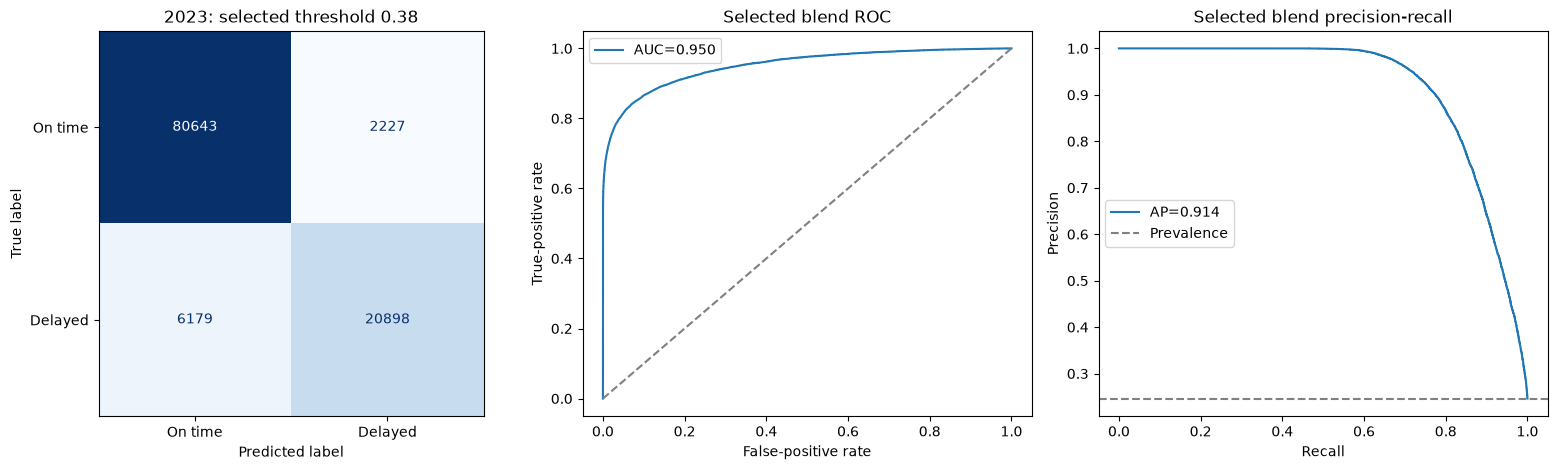

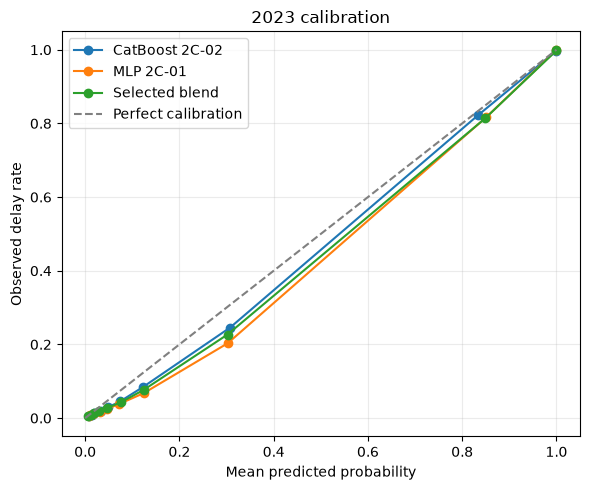

In [9]:
selected_predictions = (
    selected_validation_probabilities >= selected_threshold
).astype(int)
false_positive_rate, true_positive_rate, _ = roc_curve(
    y_validation, selected_validation_probabilities
)
curve_precision, curve_recall, _ = precision_recall_curve(
    y_validation, selected_validation_probabilities
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    selected_predictions,
    display_labels=["On time", "Delayed"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title(f"2023: selected threshold {selected_threshold:.2f}")
axes[1].plot(
    false_positive_rate,
    true_positive_rate,
    label=(
        f"AUC={roc_auc_score(y_validation, selected_validation_probabilities):.3f}"
    ),
)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set(
    xlabel="False-positive rate",
    ylabel="True-positive rate",
    title="Selected blend ROC",
)
axes[1].legend()
axes[2].plot(
    curve_recall,
    curve_precision,
    label=(
        "AP="
        f"{average_precision_score(y_validation, selected_validation_probabilities):.3f}"
    ),
)
axes[2].axhline(
    y_validation.mean(), linestyle="--", color="gray", label="Prevalence"
)
axes[2].set(
    xlabel="Recall",
    ylabel="Precision",
    title="Selected blend precision-recall",
)
axes[2].legend()
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
for model_name, probabilities in validation_probability_sets.items():
    predicted, observed = calibration_curve(
        y_validation, probabilities, n_bins=10, strategy="quantile"
    )
    ax.plot(predicted, observed, marker="o", label=model_name)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.set(
    xlabel="Mean predicted probability",
    ylabel="Observed delay rate",
    title="2023 calibration",
)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Component diversity and publishable values

Correlation and mean absolute probability difference describe whether the fixed components produce meaningfully different estimates. The 2023 diversity values are diagnostic only and do not change the selected weight.

In [10]:
diversity_summary = pd.Series({
    "2019 OOF probability correlation": np.corrcoef(
        catboost_oof[oof_mask], mlp_oof[oof_mask]
    )[0, 1],
    "2019 OOF mean absolute probability difference": np.mean(
        np.abs(catboost_oof[oof_mask] - mlp_oof[oof_mask])
    ),
    "2023 probability correlation": np.corrcoef(
        catboost_validation_probabilities, mlp_validation_probabilities
    )[0, 1],
    "2023 mean absolute probability difference": np.mean(
        np.abs(catboost_validation_probabilities - mlp_validation_probabilities)
    ),
}, name="component diversity")
display(diversity_summary.to_frame())

selected_default = evaluation_results.loc[("Selected blend", "Default")]
selected_operating = evaluation_results.loc[
    ("Selected blend", "Training-selected F1")
]
publishable_summary = pd.Series({
    "CatBoost weight": selected_catboost_weight,
    "MLP weight": selected_mlp_weight,
    "candidate weights": len(CATBOOST_WEIGHTS),
    "training mean fold AP": blend_results.iloc[0]["mean_average_precision"],
    "training aggregate OOF AP": average_precision_score(
        oof_y,
        selected_catboost_weight * catboost_oof[oof_mask]
        + selected_mlp_weight * mlp_oof[oof_mask],
    ),
    "validation prevalence": y_validation.mean(),
    "validation AP": selected_default["average_precision"],
    "validation ROC AUC": selected_default["roc_auc"],
    "validation Brier": selected_default["brier_score"],
    "selected threshold": selected_threshold,
    "selected-threshold accuracy": selected_operating["accuracy"],
    "selected-threshold balanced accuracy": selected_operating[
        "balanced_accuracy"
    ],
    "selected-threshold precision": selected_operating["precision"],
    "selected-threshold recall": selected_operating["recall"],
    "selected-threshold F1": selected_operating["f1"],
    "selected-threshold MCC": selected_operating["mcc"],
    "2019 component probability correlation": diversity_summary[
        "2019 OOF probability correlation"
    ],
    "2023 component probability correlation": diversity_summary[
        "2023 probability correlation"
    ],
    "OOF fit seconds": oof_seconds,
    "final fit seconds": final_fit_seconds,
}, name="Ensemble 2C Experiment 01 Appendix F values")
publishable_summary.to_frame()

,component diversity
2019 OOF probability correlation,0.9570
2019 OOF mean absolute probability difference,0.0444
2023 probability correlation,0.9848
2023 mean absolute probability difference,0.0279


,Ensemble 2C Experiment 01 Appendix F values
CatBoost weight,0.5000
MLP weight,0.5000
candidate weights,5.0000
training mean fold AP,0.9131
training aggregate OOF AP,0.9107
validation prevalence,0.2463
validation AP,0.9143
validation ROC AUC,0.9500
validation Brier,0.0603
selected threshold,0.3800


## Interpretation checklist

1. Does a mixed weight improve mean 2019 fold average precision over both pure controls?
2. Does the selected training result persist in 2023 ranking or probability quality?
3. Is the improvement large enough to justify operating two classifiers?
4. If a pure component wins or the gain is negligible, retain the simpler completed model.
5. Keep the existing feature datasets unchanged and keep 2024 untouched.